# SASRec → target-conditioned QFormer → LLM recommender

Binary click/rating prediction ("Yes"/"No") on CoLLM's MovieLens-1M benchmark.
**Primary metric: UAUC** (per-user AUC averaged over users); secondary: global AUC, NDCG@k.

## Architecture

```
history ids ──> SASRec (frozen after Phase 0) ──> H ∈ [B, L, d]   (ALL positions)
                                                    │ keys/values
target id ──> e_i ──> FiLM ──> Q' = γ(e_i)·Q + β(e_i)
                                                    │ queries
                                     QFormer (self-attn + cross-attn)
                                                    │
                          N ×〈UserID〉tokens + 1 ×〈TargetItemID〉token
                                                    │  spliced into inputs_embeds
                        frozen LLM + LoRA ──> P("Yes") at the answer position
```

**Why a QFormer instead of CoLLM's MLP?** CoLLM compresses the entire history into one
pooled SASRec vector and MLP-maps it to a single soft token — an information bottleneck.
The QFormer's N learnable queries cross-attend over *every* history position, so different
queries can specialize (genre affinity, recency, niche taste) and the LLM receives N tokens
of user representation.

**Two-level target injection (by design).** The target item enters the model twice:
1. **Early** — its SASRec embedding FiLM-modulates the QFormer queries *before*
   cross-attention (`Q' = γ(e_i)·Q + β(e_i)`), so the bridge reads out *"how does this
   history relate to items like this candidate"* rather than a generic profile. γ is
   parameterized as `1 + Δγ` with `Δγ` initialized to zero, so training starts at the
   target-agnostic model and learns how much conditioning helps (`target_aware=False`
   gives the agnostic control).
2. **Late** — its title and one projected item soft token appear in the prompt, letting
   the LLM do the final semantic matching.

**Training** is phase-driven (SASRec CTR pre-training → LoRA warm-up on text-only prompts
→ QFormer-only training on the hybrid prompt), the loss adds a **within-user pairwise
(BPR) term** that directly targets UAUC, and the final model is a **weight-averaged soup**
of the top-k checkpoints selected by *smoothed* validation UAUC with a bootstrap noise band.


## ⬇ Google Colab setup (skip if running locally)

Open this notebook straight from GitHub (`File → Open notebook → GitHub`) and run the
cell below: it clones the repo, installs the two packages Colab lacks, and unpacks the
CoLLM ML-1M data. On a **T4 (16 GB)** use `cfg.load_4bit = True` for the full Vicuna-7B
run; an A100 runs it in bf16 without quantization.

In [1]:
import sys, os
if "google.colab" in sys.modules and not os.path.exists("config.py"):
    !git clone https://github.com/htainvn/qformer-rec.git repo_src
    %cd repo_src
    %pip -q install peft accelerate bitsandbytes
    !unzip -o -q ml-1m.zip
    print("Colab setup done:", os.getcwd())

## 0 · Configuration

`smoke_test=True` (default) runs the whole pipeline on tiny synthetic data with a tiny
random GPT-2 backbone — CPU-only, a few minutes end-to-end. The clearly marked cell below
switches to the full Vicuna-7B multi-seed run on the real ML-1M pickles (needs a GPU).

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np, torch, matplotlib.pyplot as plt, json, warnings
warnings.filterwarnings("ignore")
from torch.utils.data import DataLoader

from config import Config
from data import load_data, collate
from models import SASRec
from models.llm_rec import fill_titles
from train import (seed_everything, train_phase0, train_phase1, train_phase2,
                   build_models, load_tracked_state, eval_sasrec, run_all_phases)
from evaluate import (score_dataset, full_report, paired_user_test, qualifying_users,
                      comparison_table, ndcg_at_k, stratified_uauc, support_weighted_uauc,
                      BASELINES, TARGETS, auc as auc_fn, uauc as uauc_fn)

cfg = Config.smoke()          # <- default: runs out of the box on CPU
SEEDS = list(range(cfg.seed, cfg.seed + cfg.n_seeds))
print(f"backbone={cfg.backbone}  smoke_test={cfg.smoke_test}  seeds={SEEDS}")

backbone=hf-internal-testing/tiny-random-gpt2  smoke_test=True  seeds=[42, 43]


### ⚠️ FULL RUN — uncomment to train Vicuna-7B on the real ML-1M (GPU required)
This is the configuration used for the reported numbers: `lmsys/vicuna-7b-v1.5` frozen +
LoRA(r=8, α=16 on q_proj/v_proj), 3 seeds, model soup of top-3 checkpoints. Expect several
hours per seed on a single A100 (use `load_4bit=True` to fit smaller GPUs).

In [3]:
# cfg = Config()                       # full ML-1M + Vicuna-7B
# cfg.n_seeds = 3                        # 3-5 seeds for the reported mean ± std
# # cfg.load_4bit = True                 # QLoRA-quantize the frozen backbone if VRAM-bound
# # cfg.unfreeze_sasrec = True           # Phase 2b variant
# # cfg.qformer_align_pretrain = True    # optional contrastive QFormer init
# SEEDS = list(range(cfg.seed, cfg.seed + cfg.n_seeds))
# print(f"backbone={cfg.backbone}  seeds={SEEDS}")

## 1 · Data

CoLLM's preprocessed ML-1M (timestamp-split, label = rating > 3): 839 users, 3,256 items,
33,891 / 10,401 / 7,331 train/val/test. Ids are 1-based with 0 as the padding/no-history
placeholder; histories are capped to the 10 most recent liked items and left-padded.
In smoke mode a latent-factor synthetic dataset with the same schema is generated instead.

In [4]:
seed_everything(cfg.seed)
DEVICE = cfg.resolve_device()
train_ds, val_ds, test_ds, n_users, n_items, id2title = load_data(cfg)

print(f"device={DEVICE}")
print(f"train/val/test = {len(train_ds)} / {len(val_ds)} / {len(test_ds)}")
print(f"n_users={n_users}  n_items={n_items}  titles={len(id2title)}")
labels = train_ds.label
print(f"train positive rate: {labels.mean():.3f}")
his_lens = [int(m) for m in (np.array([sum(1 for i in h if i != 0) for h in train_ds.his]))]
print(f"history length (post-cap): mean {np.mean(his_lens):.1f}, max {max(his_lens)}")

device=mps
train/val/test = 1500 / 400 / 400
n_users=60  n_items=120  titles=120
train positive rate: 0.500
history length (post-cap): mean 6.5, max 10


In [5]:
# A sample prompt, exactly as the LLM sees it (soft-token slots marked):
s = train_ds[min(500, len(train_ds) - 1)]
seg_a, seg_b, seg_c = fill_titles(s["his_titles"], s["target_title"], hybrid=True)
print(seg_a + f"[{cfg.n_queries} × <UserID soft tokens>]" + seg_b
      + "[1 × <TargetItemID soft token>]" + seg_c)
print("\nlabel:", s["label"])

#Question: A user has given high ratings to the following movies: "Synthetic Movie #75 (1995)", "Synthetic Movie #58 (1978)", "Synthetic Movie #48 (2018)", "Synthetic Movie #49 (2019)", "Synthetic Movie #32 (2002)", "Synthetic Movie #105 (1975)", "Synthetic Movie #86 (2006)", "Synthetic Movie #30 (2000)". Additionally, we have information about the user's preferences encoded in the feature [2 × <UserID soft tokens>]. Using all available information, make a prediction about whether the user would enjoy the movie titled "Synthetic Movie #69 (1989)" with the feature [1 × <TargetItemID soft token>]? Answer with "Yes" or "No". 
#Answer:

label: 0.0


## 2 · Phase 0 — SASRec pre-training (sequential CTR, BCE)

SASRec trains standalone: dot(last hidden state, target item embedding) → BCE. The best
epoch by val AUC is saved to `checkpoints/sasrec.pt` and frozen for Phases 1–2 (unless
`unfreeze_sasrec` re-opens it in Phase 2b).

[phase0] epoch 1/3 loss 0.6940 val AUC 0.5408 val UAUC 0.5361


[phase0] epoch 2/3 loss 0.6850 val AUC 0.5669 val UAUC 0.5414


[phase0] epoch 3/3 loss 0.6806 val AUC 0.5756 val UAUC 0.5400
[phase0] saved best (val AUC 0.5756) -> checkpoints/sasrec.pt


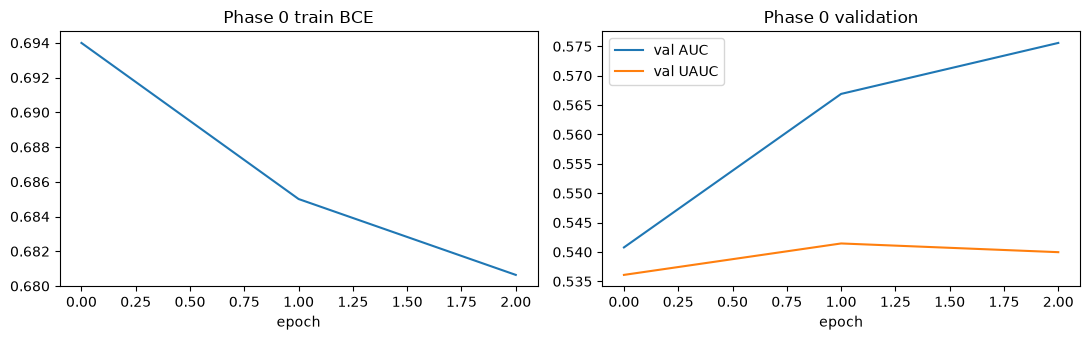

In [6]:
sasrec, hist0 = train_phase0(cfg, train_ds, val_ds, n_items, DEVICE)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(hist0["loss"]); ax[0].set_title("Phase 0 train BCE"); ax[0].set_xlabel("epoch")
ax[1].plot(hist0["val_auc"], label="val AUC"); ax[1].plot(hist0["val_uauc"], label="val UAUC")
ax[1].set_title("Phase 0 validation"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

## 3 · Phase 1 — LoRA warm-up on the text-only prompt

The LLM (backbone frozen; only LoRA trains) first learns the *task format* — answer
"Yes"/"No" about a movie given history titles — with **no** collaborative tokens. This way
Phase 2's gradients reflect collaborative signal rather than prompt-format learning.
The loss is already BCE + λ·within-user BPR (the pairwise term needs the user-grouped
batch sampler, which guarantees same-user positive/negative pairs inside a batch).

Loading weights:   0%|          | 0/64 [00:00<?, ?it/s]

[phase1] 5,120 trainable params, 58 qualifying val users for selection


[select] step 20: val UAUC 0.4729 (smoothed 0.4729) val AUC 0.5193


[select] step 40: val UAUC 0.4711 (smoothed 0.4720) val AUC 0.5200


[select] step 60: val UAUC 0.4720 (smoothed 0.4716) val AUC 0.5205


[select] step 80: val UAUC 0.4720 (smoothed 0.4720) val AUC 0.5208


[select] step 100: val UAUC 0.4729 (smoothed 0.4724) val AUC 0.5213
[phase1] early stop at step 100 (patience)
[phase1] epoch 1/1 mean loss 0.7038
[select] noise band ±0.0711: 5 checkpoint(s) tied at top
[phase1] saved LoRA -> checkpoints/lora_phase1.pt


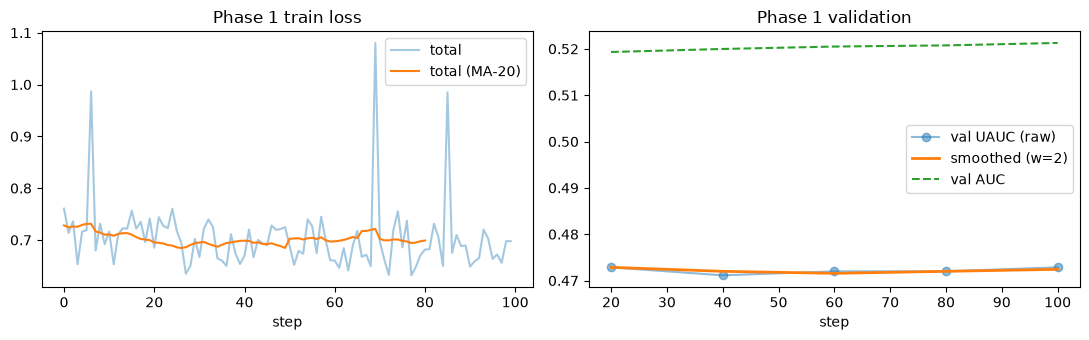

In [7]:
llm, _, qformer = build_models(cfg, n_items, DEVICE)
sasrec = sasrec.to(DEVICE)

sel1, hist1 = train_phase1(cfg, llm, sasrec, qformer, train_ds, val_ds, DEVICE)

steps1, raw1, smooth1, auc1 = sel1.curves()
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(hist1["loss"], alpha=.4, label="total")
ax[0].plot(np.convolve(hist1["loss"], np.ones(20)/20, mode="valid"), label="total (MA-20)")
ax[0].set_title("Phase 1 train loss"); ax[0].set_xlabel("step"); ax[0].legend()
ax[1].plot(steps1, raw1, "o-", alpha=.5, label="val UAUC (raw)")
ax[1].plot(steps1, smooth1, "-", lw=2, label=f"smoothed (w={cfg.sel_window})")
ax[1].plot(steps1, auc1, "--", label="val AUC")
ax[1].set_title("Phase 1 validation"); ax[1].set_xlabel("step"); ax[1].legend()
plt.tight_layout(); plt.show()

## 4 · Phase 2 — train the QFormer bridge on the full hybrid prompt

LLM **and** LoRA are now frozen (Phase-1 weights loaded); only the QFormer + projection
heads receive gradients — which flow through `inputs_embeds` at the soft-token positions.
SASRec stays frozen (Phase 2b flips `cfg.unfreeze_sasrec`). We deliberately do **not**
train LoRA and the QFormer jointly in one step: per CoLLM's ablations the LoRA gradient
dominates early and the mapping module never learns to carry collaborative information
(worst on cold users).

Checkpoint selection here is the robust machinery from `selection.py`: smoothed val UAUC
+ bootstrap noise band (AUC breaks ties only inside the band) + patience early stopping;
the final model is the **weight-averaged soup** of the top-k checkpoints.

[phase2] 8,480 trainable params, 58 qualifying val users for selection


[select] step 20: val UAUC 0.4829 (smoothed 0.4829) val AUC 0.5032


[select] step 40: val UAUC 0.4836 (smoothed 0.4832) val AUC 0.5035


[select] step 60: val UAUC 0.4836 (smoothed 0.4836) val AUC 0.5036


[select] step 80: val UAUC 0.4836 (smoothed 0.4836) val AUC 0.5035


...

[select] step 200: val UAUC 0.4836 (smoothed 0.4836) val AUC 0.5034


[select] step 220: val UAUC 0.4821 (smoothed 0.4829) val AUC 0.5035


[select] step 240: val UAUC 0.4821 (smoothed 0.4821) val AUC 0.5035


[select] step 260: val UAUC 0.4821 (smoothed 0.4821) val AUC 0.5035


[select] step 280: val UAUC 0.4821 (smoothed 0.4821) val AUC 0.5035
[phase2] early stop at step 280 (patience)
[phase2] epoch 1/2 mean loss 0.7068
[select] noise band ±0.0712: 12 checkpoint(s) tied at top
[select] souping 2 checkpoints from steps [60, 80]
[phase2] saved souped QFormer -> checkpoints/qformer.pt


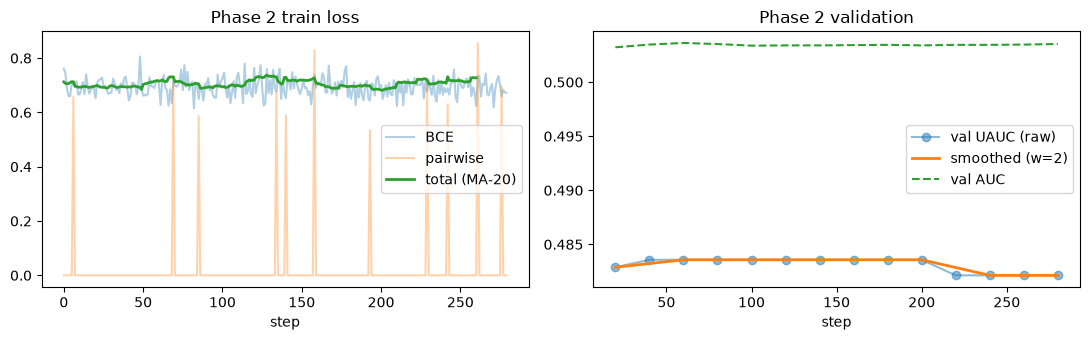

In [8]:
if cfg.qformer_align_pretrain:
    from train import align_pretrain_qformer
    align_pretrain_qformer(cfg, sasrec, qformer, train_ds, DEVICE)

sel2, hist2 = train_phase2(cfg, llm, sasrec, qformer, train_ds, val_ds, DEVICE)

steps2, raw2, smooth2, auc2 = sel2.curves()
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(hist2["bce"], alpha=.35, label="BCE")
ax[0].plot(hist2["pair"], alpha=.35, label="pairwise")
ax[0].plot(np.convolve(hist2["loss"], np.ones(20)/20, mode="valid"), lw=2, label="total (MA-20)")
ax[0].set_title("Phase 2 train loss"); ax[0].set_xlabel("step"); ax[0].legend()
ax[1].plot(steps2, raw2, "o-", alpha=.5, label="val UAUC (raw)")
ax[1].plot(steps2, smooth2, "-", lw=2, label=f"smoothed (w={cfg.sel_window})")
ax[1].plot(steps2, auc2, "--", label="val AUC")
ax[1].set_title("Phase 2 validation"); ax[1].set_xlabel("step"); ax[1].legend()
plt.tight_layout(); plt.show()

## 5 · Model soup + test evaluation (seed 0)

`train_phase2` already loaded the top-k soup into the QFormer. We score the test split
once with the souped model, and also score the Phase-0 SASRec alone — the collaborative
baseline for the paired per-user comparison.

In [9]:
uids_t, labels_t, scores_t = score_dataset(
    llm, sasrec, qformer, test_ds, batch_size=cfg.phase2_batch_size * 2, device=DEVICE)

# fixed qualifying-user set: computed once, reused for every model/seed below
TEST_USERS = qualifying_users(uids_t, labels_t)
print(f"qualifying test users (both classes present): {len(TEST_USERS)}"
      f" of {len(np.unique(uids_t))}")

# SASRec-only baseline scores on the identical samples
with torch.no_grad():
    dl = DataLoader(test_ds, batch_size=256, shuffle=False, collate_fn=collate)
    sasrec_scores = np.concatenate([
        torch.sigmoid(sasrec.ctr_logit(b.his.to(DEVICE), b.his_mask.to(DEVICE),
                                       b.iid.to(DEVICE))).cpu().numpy() for b in dl])

seed_scores = {SEEDS[0]: scores_t}
rep0 = full_report(uids_t, labels_t, scores_t, TEST_USERS, n_boot=cfg.n_boot,
                   ndcg_ks=cfg.ndcg_ks, seed=cfg.seed)
print(json.dumps({k: v for k, v in rep0.items() if k != "stratified_uauc"},
                 indent=2, default=str))

qualifying test users (both classes present): 54 of 60


{
  "auc": 0.47459999999999997,
  "uauc": 0.47385557515187143,
  "uauc_ci": [
    0.39143755511463835,
    0.5511129482657261
  ],
  "n_qualifying_users": 54,
  "support_weighted_uauc": 0.46270464555804874,
  "ndcg": {
    "5": 0.6470864794173536,
    "10": 0.7576474235658136
  }
}


## 6 · Multi-seed runs

The targets sit above published SOTA, so no single lucky run counts: every reported number
is a mean over seeds, and every UAUC carries a bootstrap CI over users. Each extra seed
re-runs all three phases end-to-end.

In [10]:
for seed in SEEDS[1:]:
    print(f"\n=== seed {seed} " + "=" * 50)
    run = run_all_phases(cfg, seed=seed)
    llm_s, sasrec_s, qformer_s = run["models"]
    _, _, s = score_dataset(llm_s, sasrec_s, qformer_s, test_ds,
                            batch_size=cfg.phase2_batch_size * 2, device=run["device"])
    seed_scores[seed] = s
    del run, llm_s, sasrec_s, qformer_s
    if torch.cuda.is_available(): torch.cuda.empty_cache()

print(f"\ncollected test scores for seeds: {sorted(seed_scores)}")


=== seed 43 ==================================================
[run] seed 43, device mps, smoke_test=True


[phase0] epoch 1/3 loss 0.6930 val AUC 0.5287 val UAUC 0.5193


[phase0] epoch 2/3 loss 0.6856 val AUC 0.5672 val UAUC 0.5543


[phase0] epoch 3/3 loss 0.6803 val AUC 0.5857 val UAUC 0.5659
[phase0] saved best (val AUC 0.5857) -> checkpoints/sasrec.pt


Loading weights:   0%|          | 0/64 [00:00<?, ?it/s]

...

[select] step 40: val UAUC 0.4817 (smoothed 0.4824) val AUC 0.5031


[select] step 60: val UAUC 0.4817 (smoothed 0.4817) val AUC 0.5032


[select] step 80: val UAUC 0.4817 (smoothed 0.4817) val AUC 0.5031


[select] step 100: val UAUC 0.4775 (smoothed 0.4796) val AUC 0.5034
[phase2] early stop at step 100 (patience)
[phase2] epoch 1/2 mean loss 0.7054
[select] noise band ±0.0706: 5 checkpoint(s) tied at top
[select] souping 2 checkpoints from steps [100, 20]
[phase2] saved souped QFormer -> checkpoints/qformer.pt



collected test scores for seeds: [42, 43]


## 7 · Results

* **Headline**: test AUC / UAUC as mean ± std over seeds; UAUC with a bootstrap CI over
  users (computed on per-user AUCs averaged across seeds — the seed-level uncertainty and
  user-level uncertainty are reported separately, not conflated).
* **Paired comparison** vs the SASRec baseline: mean per-user AUC difference with a
  bootstrap test over users — the correct way to claim a win, since pairing removes
  between-user variance.
* **Diagnostics** (alongside, never as headline): support-weighted UAUC, UAUC stratified
  by user support (all qualifying users are always reported too — nobody gets silently
  dropped), NDCG@{5,10}.

In [11]:
from evaluate import per_user_auc

per_seed_auc  = {s: auc_fn(labels_t, sc) for s, sc in seed_scores.items()}
per_seed_uauc = {s: uauc_fn(uids_t, labels_t, sc, TEST_USERS) for s, sc in seed_scores.items()}
auc_mean, auc_std   = np.mean(list(per_seed_auc.values())),  np.std(list(per_seed_auc.values()))
uauc_mean, uauc_std = np.mean(list(per_seed_uauc.values())), np.std(list(per_seed_uauc.values()))
print("per-seed AUC :", {s: round(v, 4) for s, v in per_seed_auc.items()})
print("per-seed UAUC:", {s: round(v, 4) for s, v in per_seed_uauc.items()})

# bootstrap CI over USERS on the seed-averaged per-user AUCs
pu_by_seed = [per_user_auc(uids_t, labels_t, sc, TEST_USERS) for sc in seed_scores.values()]
user_mat = np.array([[pu[int(u)][0] for pu in pu_by_seed] for u in TEST_USERS]).mean(axis=1)
rng = np.random.default_rng(cfg.seed)
boot = rng.choice(user_mat, size=(cfg.n_boot, len(user_mat)), replace=True).mean(axis=1)
uauc_ci = (float(np.quantile(boot, .025)), float(np.quantile(boot, .975)))
print(f"\nUAUC {uauc_mean:.4f} ± {uauc_std:.4f} (seed std) | 95% user-bootstrap CI"
      f" [{uauc_ci[0]:.4f}, {uauc_ci[1]:.4f}]")

per-seed AUC : {42: 0.4746, 43: 0.4745}
per-seed UAUC: {42: 0.4739, 43: 0.4744}

UAUC 0.4741 ± 0.0002 (seed std) | 95% user-bootstrap CI [0.3894, 0.5472]


In [12]:
# Paired per-user comparison vs the SASRec baseline (seed-0 scores)
paired = paired_user_test(uids_t, labels_t, seed_scores[SEEDS[0]], sasrec_scores,
                          TEST_USERS, n_boot=cfg.n_boot, seed=cfg.seed)
print("paired vs SASRec-only:", json.dumps(paired, indent=2))
verdict = ("BEATS baseline (CI excludes 0)" if paired["ci"][0] > 0 else
           "does NOT significantly beat baseline" if paired["ci"][1] > 0 else
           "significantly WORSE than baseline")
print("→", verdict)

paired vs SASRec-only: {
  "mean_diff": -0.06759798157946306,
  "ci": [
    -0.16507348006074857,
    0.042690543552812064
  ],
  "p_boot": 0.25,
  "n_users": 54
}
→ does NOT significantly beat baseline


In [13]:
print(comparison_table(auc_mean, auc_std, uauc_mean, uauc_std, uauc_ci, len(SEEDS)))

mean_scores = np.mean([seed_scores[s] for s in SEEDS], axis=0)
print("\n--- diagnostics (seed-averaged scores; alongside, not headline) ---")
print(f"support-weighted UAUC: {support_weighted_uauc(uids_t, labels_t, mean_scores, TEST_USERS):.4f}")
for k, (v, n) in stratified_uauc(uids_t, labels_t, mean_scores, TEST_USERS).items():
    print(f"UAUC (support {k}): {v:.4f}  ({n} users; standard all-user UAUC above)")
for k, v in ndcg_at_k(uids_t, labels_t, mean_scores, ks=cfg.ndcg_ks).items():
    print(f"NDCG@{k}: {v:.4f}")

Model                     | UAUC                               | AUC             | Notes          
--------------------------+------------------------------------+-----------------+----------------
Ours (SASRec+QFormer+LLM) | 0.4741 ± 0.0002 (CI 0.3894–0.5472) | 0.4745 ± 0.0001 | mean of 2 seeds
CoLLM-SASRec              | 0.6990                             | 0.7235          | published      
BinLLM                    | 0.6956                             | 0.7425          | published      
CoLLM-MF                  | 0.6875                             | —               | published      
TARGET                    | 0.71                               | 0.75            |                

--- diagnostics (seed-averaged scores; alongside, not headline) ---
support-weighted UAUC: 0.4643
UAUC (support >=5): 0.4411  (43 users; standard all-user UAUC above)
UAUC (support >=10): 0.4299  (11 users; standard all-user UAUC above)


NDCG@5: 0.6525
NDCG@10: 0.7611


## 8 · Conclusion

* The pipeline — SASRec → FiLM-target-conditioned QFormer → frozen LLM + LoRA — runs
  end-to-end: phase-wise training, within-user pairwise loss, smoothed-UAUC checkpoint
  selection with a bootstrap noise band, and a top-k weight-averaged soup.
* In `smoke_test` mode (this default run) the numbers are chance-level by construction:
  a randomly initialized 32-dim GPT-2 on synthetic data exists only to prove the plumbing.
  Real conclusions require the marked full-run cell: Vicuna-7B on CoLLM's ML-1M,
  ≥3 seeds.
* Claiming a win means: multi-seed mean UAUC with its user-bootstrap CI above
  CoLLM-SASRec's 0.6990, **and** a paired per-user bootstrap CI excluding zero — not one
  lucky checkpoint.
* If the full run plateaus below the 0.71 UAUC target, the documented escalation path is
  **Design 2 (DIN-fused values)** in `models/README.md`: concatenate DIN's pre-pool
  target-weighted per-position states with SASRec's states as QFormer keys/values —
  strictly more expressive target injection, at the cost of a second encoder.